In [0]:
from pyspark.sql.functions import col
appointments_data = [
(1001, "Hyderabad", "Cardiology", "Apollo", 1500, "Completed"),
(1002, "Bangalore", "Neurology", "Yashoda", 2200, "Completed"),
(1003, "Mumbai", "Dermatology", "Care", 900, "Pending"),
(1004, "Delhi", "Orthopedics", "Max", 2500, "Completed"),
(1005, "Chennai", "Pediatrics", "Apollo", 1200, "Cancelled"),
(1006, "Hyderabad", "Cardiology", "Care", 3000, "Completed"),
(1007, "Bangalore", "Dermatology", "Apollo", 1000, "Completed"),
(1008, "Mumbai", "Neurology", "Max", 2600, "Pending"),
(1009, "Delhi", "Cardiology", "Yashoda", 2800, "Completed"),
(1010, "Chennai", "Orthopedics", "Care", 2400, "Completed"),
(1011, "Hyderabad", "Pediatrics", "Apollo", 1100, "Completed"),
(1012, "Bangalore", "Cardiology", "Max", 3200, "Completed"),
(1013, "Mumbai", "Pediatrics", "Yashoda", 1300, "Cancelled"),
(1014, "Delhi", "Neurology", "Apollo", 2700, "Completed"),
(1015, "Chennai", "Dermatology", "Care", 950, "Pending")
]
columns = [
"appointment_id",
"city",
"department",
"hospital",
"consultation_fee",
"status"
]
df = spark.createDataFrame(appointments_data, columns)
display(df)

appointment_id,city,department,hospital,consultation_fee,status
1001,Hyderabad,Cardiology,Apollo,1500,Completed
1002,Bangalore,Neurology,Yashoda,2200,Completed
1003,Mumbai,Dermatology,Care,900,Pending
1004,Delhi,Orthopedics,Max,2500,Completed
1005,Chennai,Pediatrics,Apollo,1200,Cancelled
1006,Hyderabad,Cardiology,Care,3000,Completed
1007,Bangalore,Dermatology,Apollo,1000,Completed
1008,Mumbai,Neurology,Max,2600,Pending
1009,Delhi,Cardiology,Yashoda,2800,Completed
1010,Chennai,Orthopedics,Care,2400,Completed


city,revenue
Delhi,8000
Bangalore,6400
Hyderabad,5600
Chennai,2400


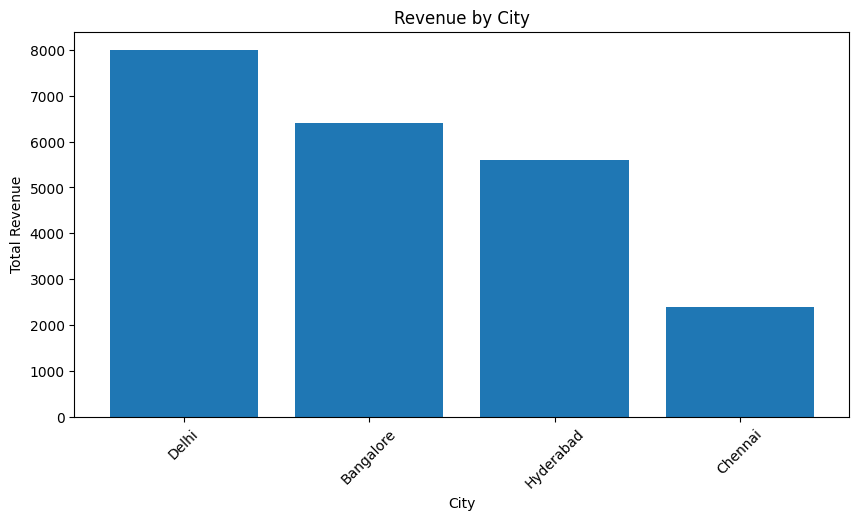

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, sum
revenue_by_city = (
    df.filter(col("status") == "Completed")
      .groupBy("city")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy("revenue", ascending=False)
)
display(revenue_by_city)
city_pd = revenue_by_city.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

department,revenue
Cardiology,10500
Neurology,4900
Orthopedics,4900
Pediatrics,1100
Dermatology,1000


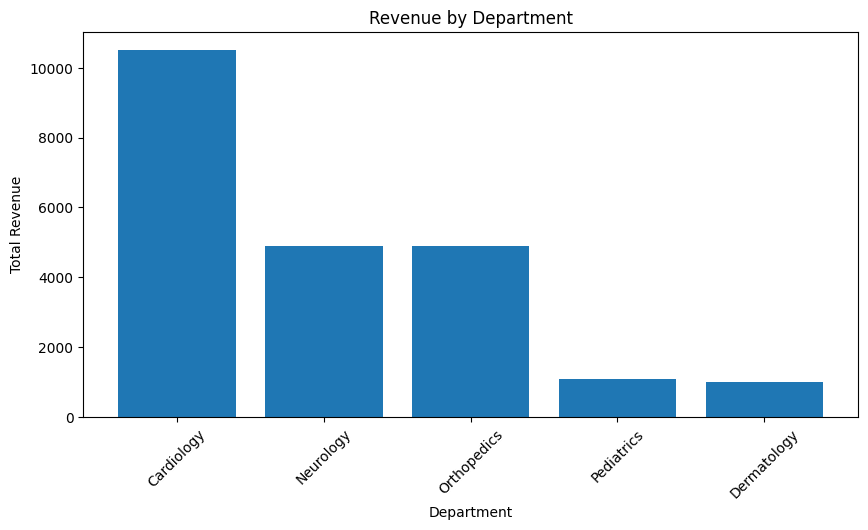

In [0]:
revenue_by_department = (
    df.filter(col("status") == "Completed")
      .groupBy("department")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy("revenue", ascending=False)
)
display(revenue_by_department)
city_pd = revenue_by_department.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["department"], city_pd["revenue"])
plt.xlabel("Department")
plt.ylabel("Total Revenue")
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()


status,appointment_count
Completed,10
Pending,3
Cancelled,2


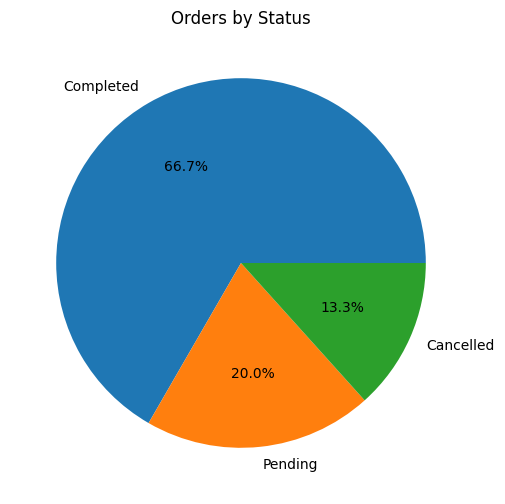

In [0]:
from pyspark.sql.functions import count
status_count = (
    df.groupBy("status")
      .agg(count("appointment_id").alias("appointment_count"))
)
display(status_count)
status_pd = status_count.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["appointment_count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Orders by Status")
plt.show()

hospital,revenue
Apollo,6300
Max,5700
Care,5400
Yashoda,5000


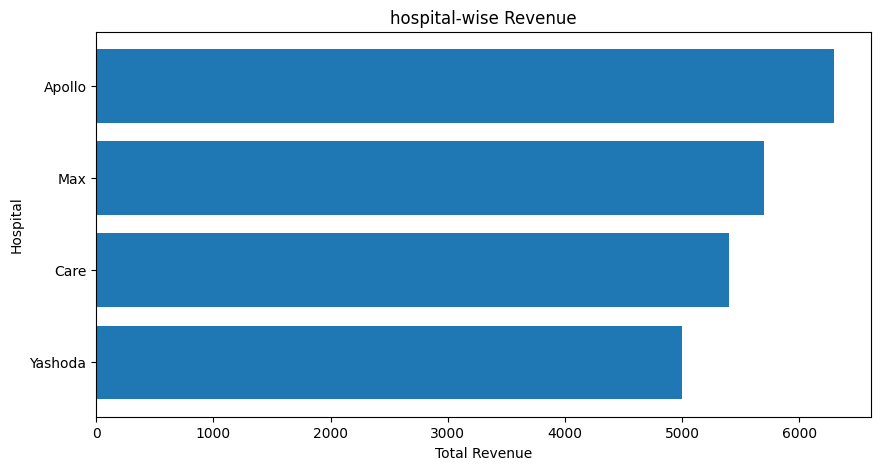

In [0]:
from pyspark.sql.functions import col, sum

revenue_by_hospital = (
    df.filter(col("status") == "Completed")
      .groupBy("hospital")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy("revenue", ascending=False)
)
display(revenue_by_hospital)
hos_pd = revenue_by_hospital.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(hos_pd["hospital"], hos_pd["revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Hospital")
plt.title("hospital-wise Revenue")
plt.gca().invert_yaxis()
plt.show()
     


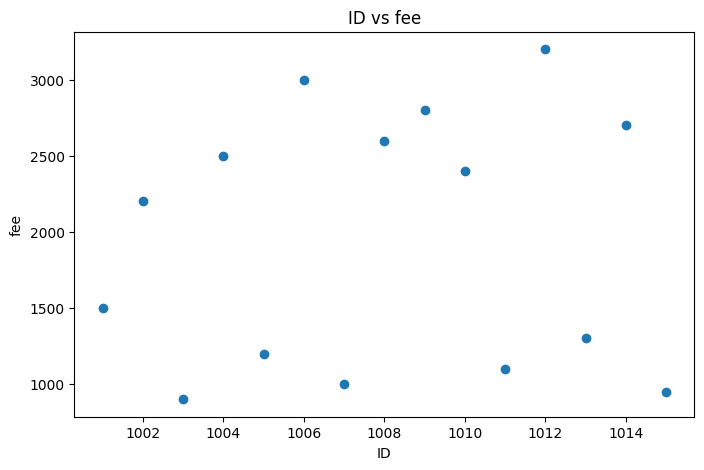

In [0]:
scatter_pd = df.select(
    "appointment_id", "consultation_fee"
).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(scatter_pd["appointment_id"], scatter_pd["consultation_fee"])
plt.xlabel("ID")
plt.ylabel("fee")
plt.title("ID vs fee")
plt.show()

appointment_id,consultation_fee
1001,1500
1002,2200
1003,900
1004,2500
1005,1200
1006,3000
1007,1000
1008,2600
1009,2800
1010,2400


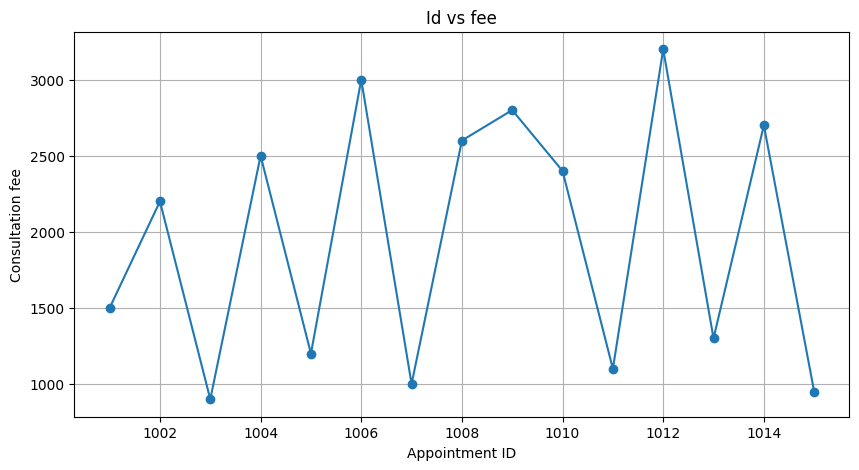

In [0]:
fee_trend_df = (
    df.select("appointment_id", "consultation_fee")
      .orderBy("appointment_id")
)
display(fee_trend_df)
plt.figure(figsize=(10, 5))
plt.plot(fee_trend_df.toPandas()["appointment_id"], fee_trend_df.toPandas()["consultation_fee"], marker="o")
plt.xlabel("Appointment ID")
plt.ylabel("Consultation fee")
plt.title("Id vs fee")
plt.grid(True)
plt.show()

city,appointment_count
Hyderabad,3
Bangalore,3
Mumbai,3
Delhi,3
Chennai,3


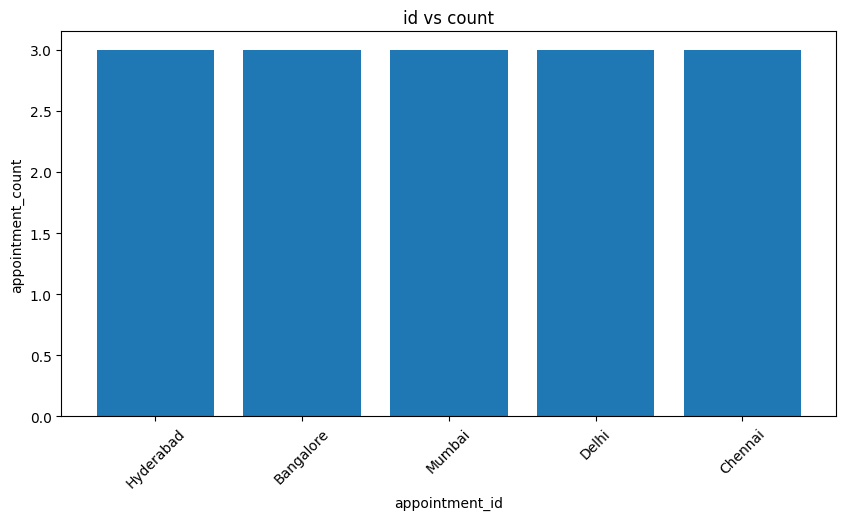

In [0]:
city_count = (
    df.groupBy("city")
      .agg(count("appointment_id").alias("appointment_count"))
)
display(city_count)
city_pd = city_count.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["appointment_count"])
plt.xlabel("appointment_id")
plt.ylabel("appointment_count")
plt.title("id vs count")
plt.xticks(rotation=45)
plt.show()

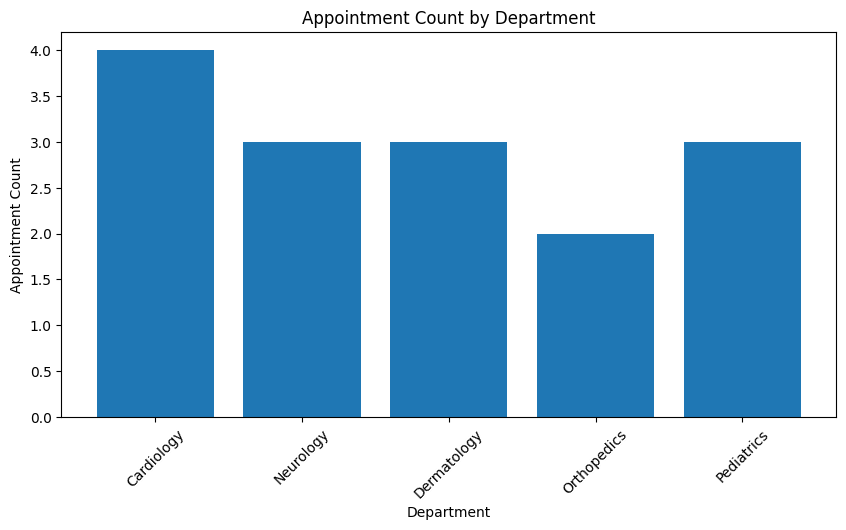

In [0]:
department_count = (
    df.groupBy("department")
      .agg(count("appointment_id").alias("appointment_count"))
)

department_pd = department_count.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(department_pd["department"], department_pd["appointment_count"])
plt.xlabel("Department")
plt.ylabel("Appointment Count")
plt.title("Appointment Count by Department")
plt.xticks(rotation=45)
plt.show()

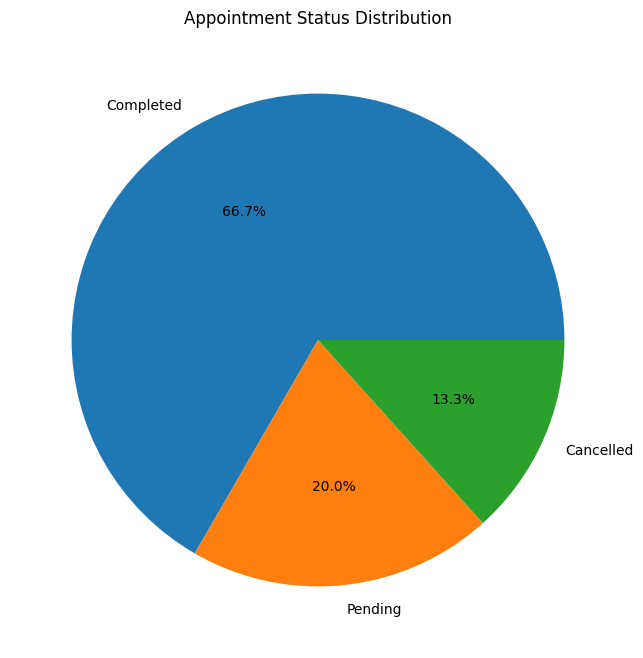

In [0]:
status_count = (
    df.groupBy("status")
      .agg(count("appointment_id").alias("appointment_count"))
)

status_pd = status_count.toPandas()

plt.figure(figsize=(8, 8))
plt.pie(
    status_pd["appointment_count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Appointment Status Distribution")
plt.show()

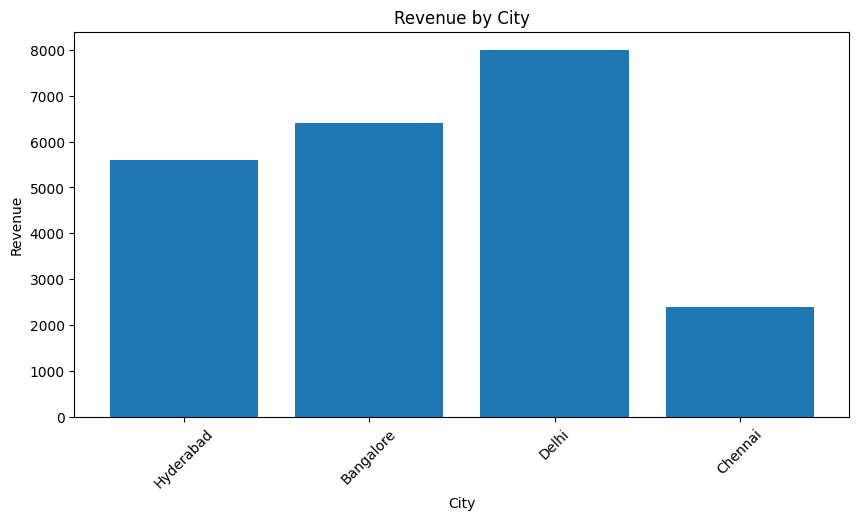

In [0]:
revenue_city = (
    df.filter(col("status") == "Completed")
      .groupBy("city")
      .agg(sum("consultation_fee").alias("revenue"))
)

revenue_city_pd = revenue_city.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(revenue_city_pd["city"], revenue_city_pd["revenue"])
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

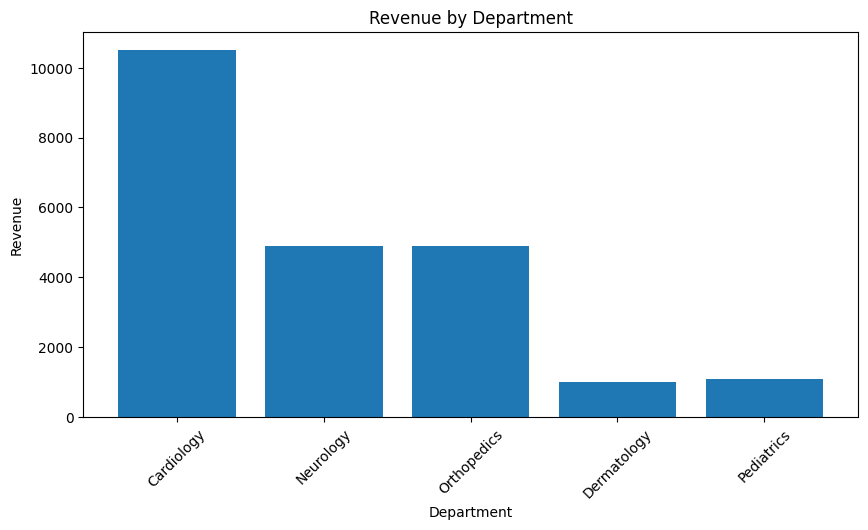

In [0]:
revenue_department = (
    df.filter(col("status") == "Completed")
      .groupBy("department")
      .agg(sum("consultation_fee").alias("revenue"))
)

revenue_department_pd = revenue_department.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(
    revenue_department_pd["department"],
    revenue_department_pd["revenue"]
)
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Revenue by Department")
plt.xticks(rotation=45)
plt.show()

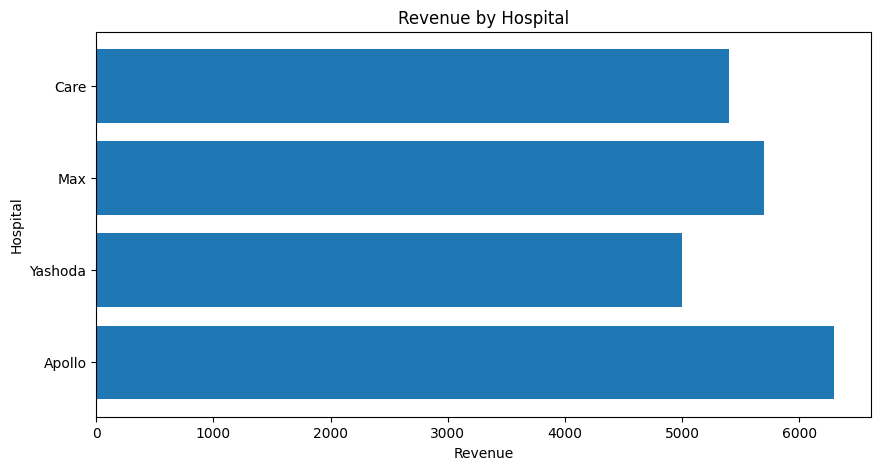

In [0]:
revenue_hospital = (
    df.filter(col("status") == "Completed")
      .groupBy("hospital")
      .agg(sum("consultation_fee").alias("revenue"))
)

revenue_hospital_pd = revenue_hospital.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(
    revenue_hospital_pd["hospital"],
    revenue_hospital_pd["revenue"]
)
plt.xlabel("Revenue")
plt.ylabel("Hospital")
plt.title("Revenue by Hospital")
plt.show()

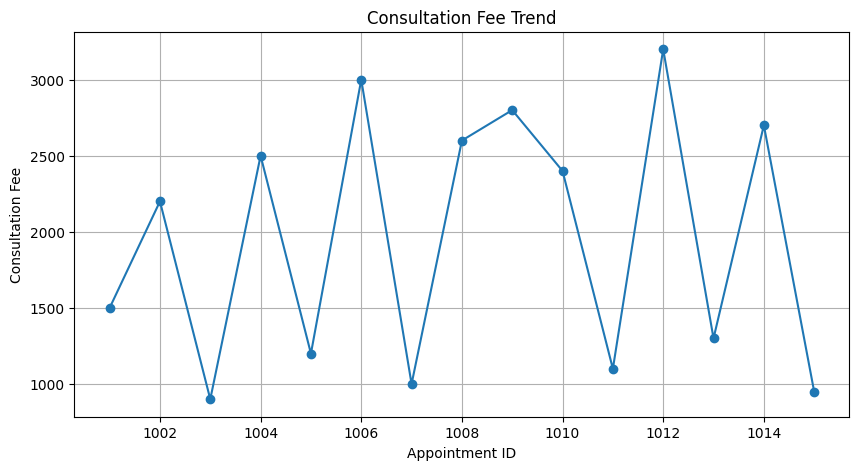

In [0]:
fee_trend = (
    df.select("appointment_id", "consultation_fee")
      .orderBy("appointment_id")
)

fee_pd = fee_trend.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(
    fee_pd["appointment_id"],
    fee_pd["consultation_fee"],
    marker="o"
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Consultation Fee Trend")
plt.grid(True)
plt.show()

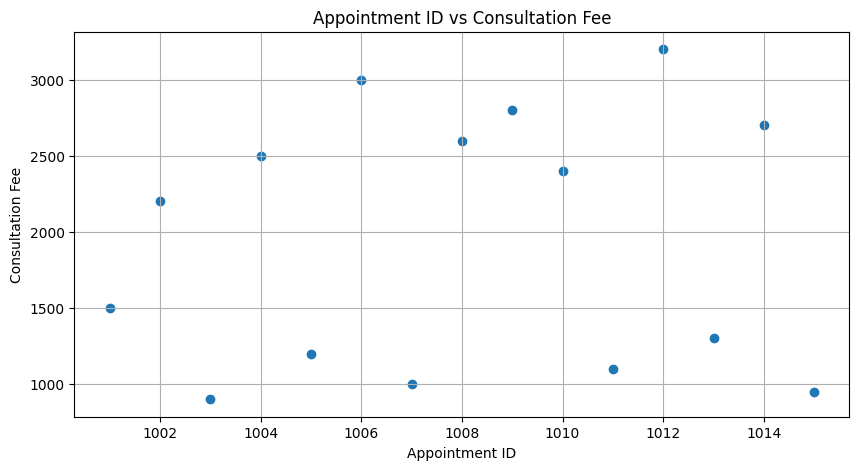

In [0]:
scatter_pd = df.select(
    "appointment_id",
    "consultation_fee"
).toPandas()

plt.figure(figsize=(10, 5))
plt.scatter(
    scatter_pd["appointment_id"],
    scatter_pd["consultation_fee"]
)
plt.xlabel("Appointment ID")
plt.ylabel("Consultation Fee")
plt.title("Appointment ID vs Consultation Fee")
plt.grid(True)
plt.show()

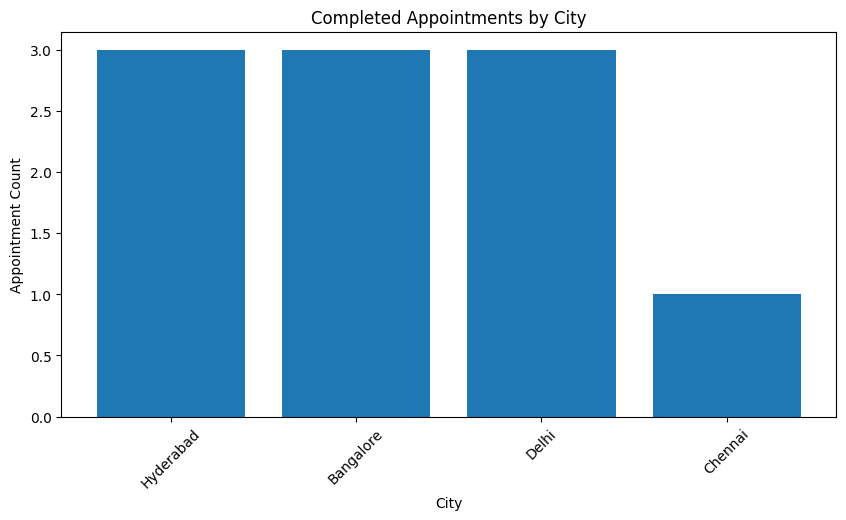

In [0]:
completed_city = (
    df.filter(col("status") == "Completed")
      .groupBy("city")
      .agg(count("appointment_id").alias("appointment_count"))
)

completed_city_pd = completed_city.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(
    completed_city_pd["city"],
    completed_city_pd["appointment_count"]
)
plt.xlabel("City")
plt.ylabel("Appointment Count")
plt.title("Completed Appointments by City")
plt.xticks(rotation=45)
plt.show()

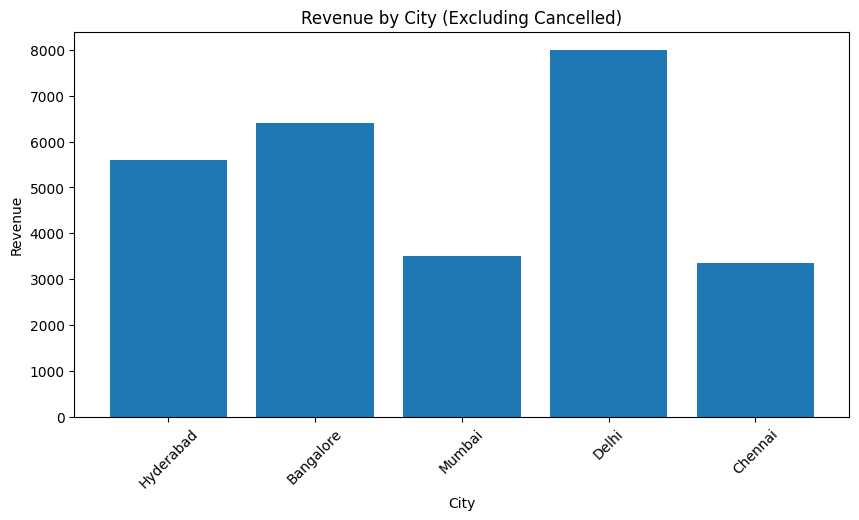

In [0]:
revenue_no_cancel = (
    df.filter(col("status") != "Cancelled")
      .groupBy("city")
      .agg(sum("consultation_fee").alias("revenue"))
)

revenue_no_cancel_pd = revenue_no_cancel.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(
    revenue_no_cancel_pd["city"],
    revenue_no_cancel_pd["revenue"]
)
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue by City (Excluding Cancelled)")
plt.xticks(rotation=45)
plt.show()

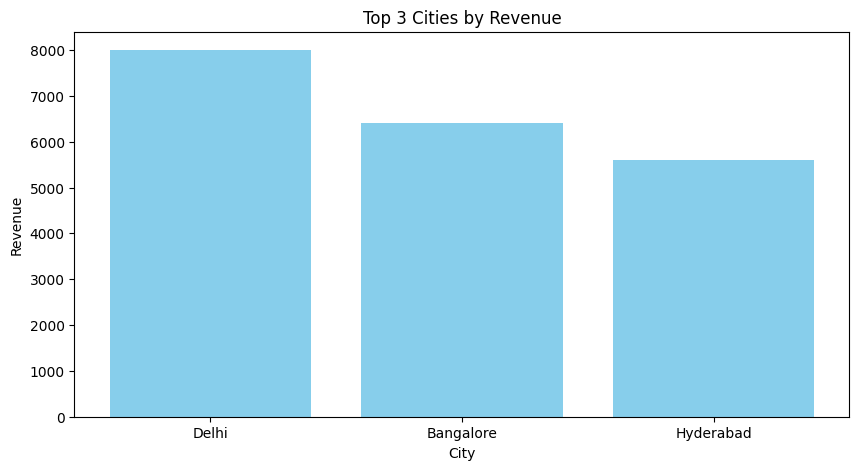

In [0]:
from pyspark.sql.functions import sum, col

top3_cities = (
    df.filter(col("status") == "Completed")
      .groupBy("city")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy(col("revenue").desc())
      .limit(3)
)

top3_city_pd = top3_cities.toPandas()

plt.figure(figsize=(10,5))
plt.bar(top3_city_pd["city"], top3_city_pd["revenue"], color="skyblue")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Top 3 Cities by Revenue")
plt.show()

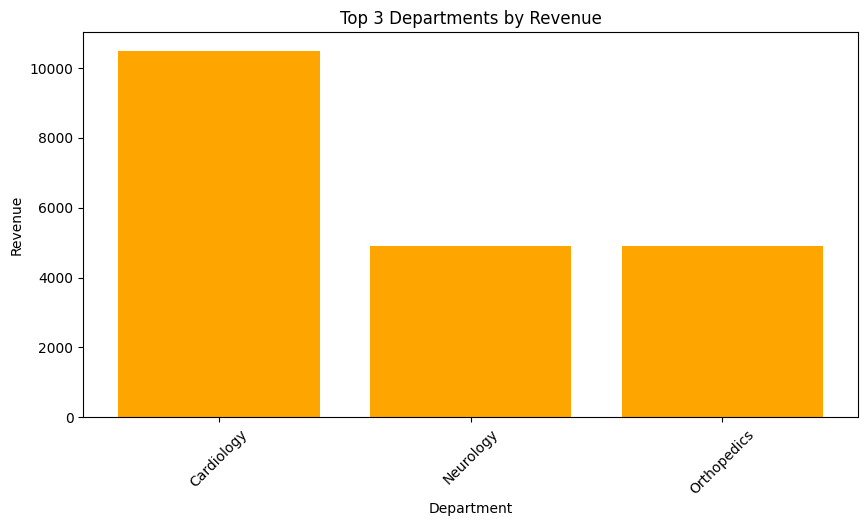

In [0]:
top3_departments = (
    df.filter(col("status") == "Completed")
      .groupBy("department")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy(col("revenue").desc())
      .limit(3)
)

top3_dept_pd = top3_departments.toPandas()

plt.figure(figsize=(10,5))
plt.bar(
    top3_dept_pd["department"],
    top3_dept_pd["revenue"],
    color="orange"
)
plt.xlabel("Department")
plt.ylabel("Revenue")
plt.title("Top 3 Departments by Revenue")
plt.xticks(rotation=45)
plt.show()

In [0]:
lowest_hospital = (
    df.filter(col("status") == "Completed")
      .groupBy("hospital")
      .agg(sum("consultation_fee").alias("revenue"))
      .orderBy("revenue")
      .limit(1)
)

lowest_hospital.show()

+--------+-------+
|hospital|revenue|
+--------+-------+
| Yashoda|   5000|
+--------+-------+



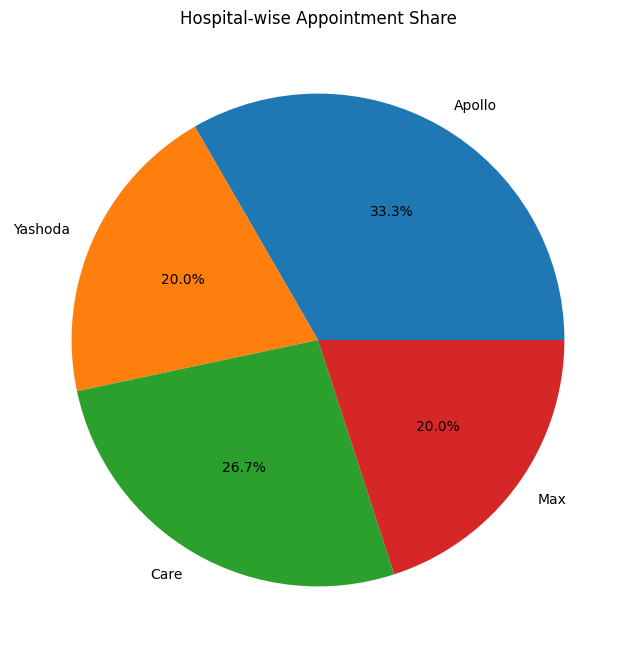

In [0]:
hospital_share = (
    df.groupBy("hospital")
      .agg(count("appointment_id").alias("appointments"))
)

hospital_pd = hospital_share.toPandas()

plt.figure(figsize=(8,8))
plt.pie(
    hospital_pd["appointments"],
    labels=hospital_pd["hospital"],
    autopct="%1.1f%%"
)
plt.title("Hospital-wise Appointment Share")
plt.show()

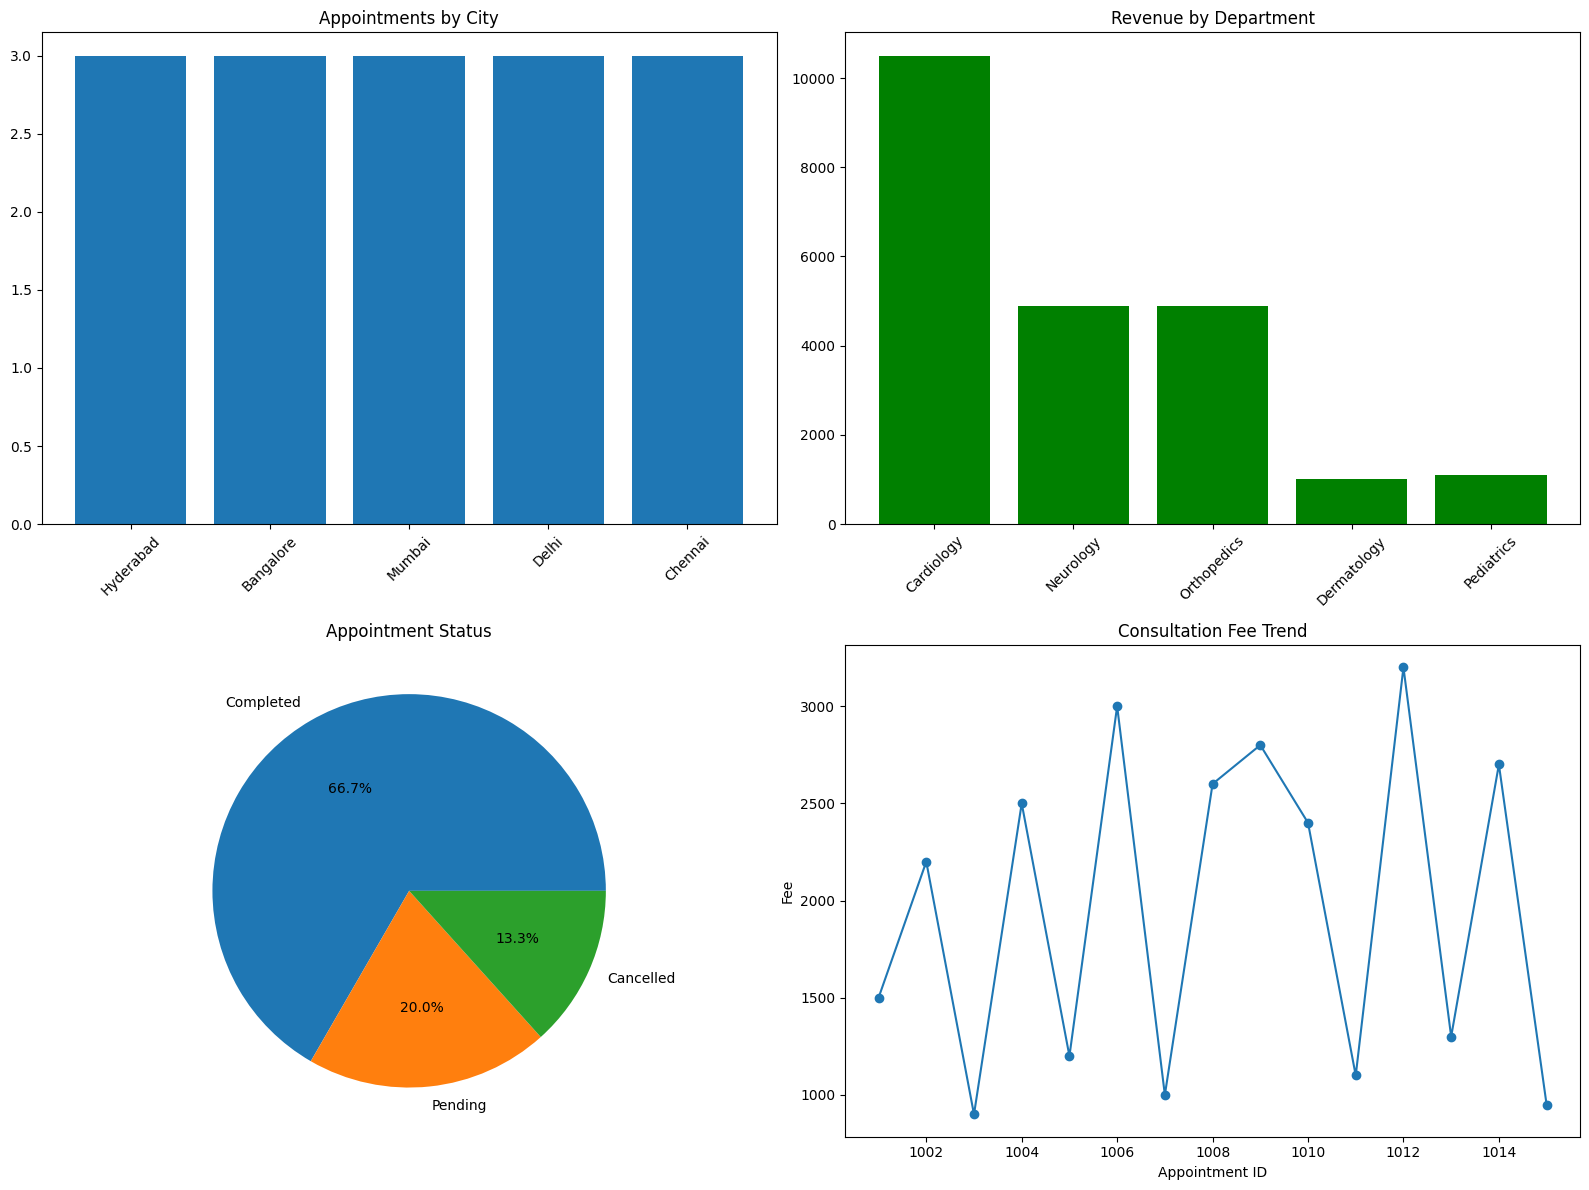

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import count, sum, col

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
city_count = (
    df.groupBy("city")
      .agg(count("appointment_id").alias("count"))
)

city_pd = city_count.toPandas()

axes[0,0].bar(city_pd["city"], city_pd["count"])
axes[0,0].set_title("Appointments by City")
axes[0,0].tick_params(axis='x', rotation=45)
dept_rev = (
    df.filter(col("status") == "Completed")
      .groupBy("department")
      .agg(sum("consultation_fee").alias("revenue"))
)

dept_pd = dept_rev.toPandas()

axes[0,1].bar(
    dept_pd["department"],
    dept_pd["revenue"],
    color="green"
)
axes[0,1].set_title("Revenue by Department")
axes[0,1].tick_params(axis='x', rotation=45)
status_dist = (
    df.groupBy("status")
      .agg(count("appointment_id").alias("count"))
)

status_pd = status_dist.toPandas()

axes[1,0].pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
axes[1,0].set_title("Appointment Status")
fee_pd = (
    df.select("appointment_id","consultation_fee")
      .orderBy("appointment_id")
      .toPandas()
)

axes[1,1].plot(
    fee_pd["appointment_id"],
    fee_pd["consultation_fee"],
    marker="o"
)
axes[1,1].set_title("Consultation Fee Trend")
axes[1,1].set_xlabel("Appointment ID")
axes[1,1].set_ylabel("Fee")
plt.tight_layout()
plt.show()